In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
np.random.seed(42)

# Simulating a messy real-world Netflix dataset
data = {
    'show_id': [f's{i}' for i in range(1, 201)],
    'type': np.random.choice(['Movie', 'TV Show'], 200, p=[0.7, 0.3]),
    'title': [f'Movie/Show Title {i}' for i in range(1, 201)],
    'director': np.random.choice(['Director A', 'Director B', 'Director C', np.nan], 200),
    'release_year': np.random.choice([2018, 2019, 2020, 2021, 2022, 2023, 2024], 200),
    'rating': np.random.choice(['PG-13', 'R', 'TV-MA', 'PG', np.nan], 200),
    'duration': np.random.choice(['90 min', '120 min', '1 Seasons', '2 Seasons', '45 min', np.nan], 200)
}

df = pd.DataFrame(data)
print("--- RAW DATA PREVIEW (Messy) ---")
display(df.head())

--- RAW DATA PREVIEW (Messy) ---


,show_id,type,title,director,release_year,rating,duration
0,s1,Movie,Movie/Show Title 1,nan,2022,TV-MA,120 min
1,s2,TV Show,Movie/Show Title 2,nan,2021,PG,nan
2,s3,TV Show,Movie/Show Title 3,Director C,2023,PG-13,1 Seasons
3,s4,Movie,Movie/Show Title 4,Director A,2024,PG,1 Seasons
4,s5,Movie,Movie/Show Title 5,nan,2020,TV-MA,120 min


In [2]:
print("--- MISSING VALUES BEFORE CLEANING ---")
print(df.isnull().sum())

# 1. Fill missing directors and ratings with placeholder/default values
df['director'] = df['director'].fillna('Unknown Director')
df['rating'] = df['rating'].fillna('TV-MA')

# 2. Drop duplicate rows if any exist
df = df.drop_duplicates()

# 3. Clean 'duration' column: Extract numeric values from strings like "90 min"
# Creating separate numeric columns for Movies (minutes) and TV Shows (seasons)
df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float)
df['duration_num'] = df['duration_num'].fillna(df['duration_num'].median())

print("\n--- MISSING VALUES AFTER CLEANING ---")
print(df.isnull().sum())
display(df.head())

--- MISSING VALUES BEFORE CLEANING ---
show_id         0
type            0
title           0
director        0
release_year    0
rating          0
duration        0
dtype: int64

--- MISSING VALUES AFTER CLEANING ---
show_id         0
type            0
title           0
director        0
release_year    0
rating          0
duration        0
duration_num    0
dtype: int64


<>:13: SyntaxWarning: invalid escape sequence '\d'
<>:13: SyntaxWarning: invalid escape sequence '\d'
C:\Users\short\AppData\Local\Temp\ipykernel_8508\2470304212.py:13: SyntaxWarning: invalid escape sequence '\d'
  df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float)


,show_id,type,title,director,release_year,rating,duration,duration_num
0,s1,Movie,Movie/Show Title 1,nan,2022,TV-MA,120 min,120.0
1,s2,TV Show,Movie/Show Title 2,nan,2021,PG,nan,45.0
2,s3,TV Show,Movie/Show Title 3,Director C,2023,PG-13,1 Seasons,1.0
3,s4,Movie,Movie/Show Title 4,Director A,2024,PG,1 Seasons,1.0
4,s5,Movie,Movie/Show Title 5,nan,2020,TV-MA,120 min,120.0


In [3]:
# 1. Content Type Breakdown (Movies vs TV Shows)
type_counts = df['type'].value_counts()
print("--- CONTENT TYPE DISTRIBUTION ---")
display(type_counts)

# 2. Content Released by Year
yearly_trend = df.groupby('release_year')['show_id'].count().reset_index(name='total_releases')
print("\n--- RELEASES BY YEAR ---")
display(yearly_trend.sort_values(by='release_year'))

--- CONTENT TYPE DISTRIBUTION ---


type
Movie      140
TV Show     60
Name: count, dtype: int64


--- RELEASES BY YEAR ---


,release_year,total_releases
0,2018,31
1,2019,32
2,2020,23
3,2021,31
4,2022,37
5,2023,21
6,2024,25


C:\Users\short\AppData\Local\Temp\ipykernel_8508\2846170020.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='type', palette='Set2')


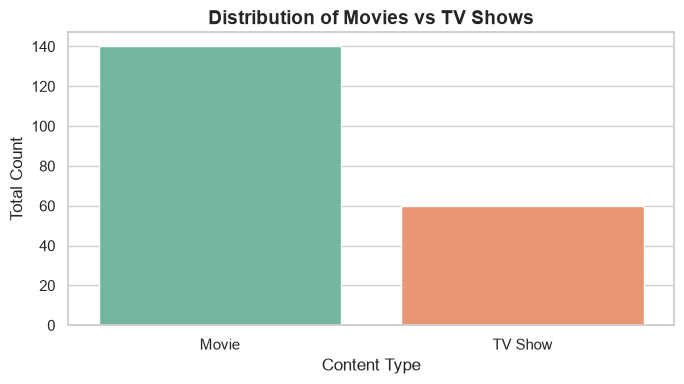

In [4]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='type', palette='Set2')
plt.title('Distribution of Movies vs TV Shows', fontsize=14, fontweight='bold')
plt.xlabel('Content Type', fontsize=12)
plt.ylabel('Total Count', fontsize=12)
plt.tight_layout()
plt.show()


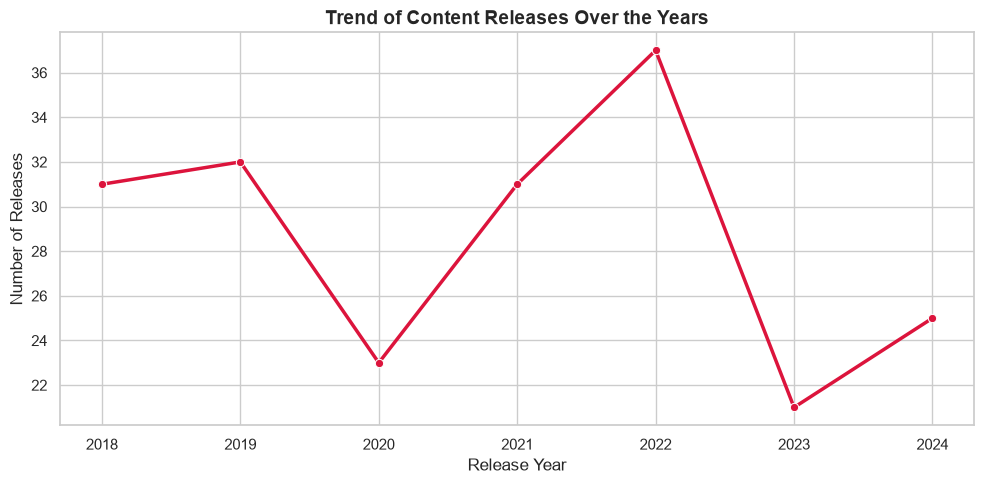

In [5]:
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=yearly_trend, 
    x='release_year', 
    y='total_releases', 
    marker='o', 
    linewidth=2.5, 
    color='crimson'
)
plt.title('Trend of Content Releases Over the Years', fontsize=14, fontweight='bold')
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Number of Releases', fontsize=12)
plt.tight_layout()
plt.show()